# Jigsaw Toxic Comment Classification — Baselines (Multi-Label)

This notebook trains three classic baselines on the Jigsaw dataset:
- **Naive Bayes**
- **Logistic Regression**
- **Linear SVM**

### Why this version is different from a "toxic vs. non-toxic" setup

The competition is **multi-label**, not binary and not multi-class. Every comment gets a
**0 or 1 for each of 6 labels at the same time**:

`toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`

A comment can be `toxic=1` **and** `insult=1` **and** `obscene=1` all at once. So instead of
training *one* classifier that picks *one* class, we train **6 independent binary classifiers**
— one per label, each answering "yes/no" for that label only. Scikit-learn does this for us
automatically with `OneVsRestClassifier`.

### What you need
- `train.csv`, `test.csv`, `test_labels.csv` from the [Kaggle competition page](https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge/data)
- Either upload them directly, or use the Kaggle API cell below.


## 1. Setup

This notebook runs on both Google Colab and locally (VSCode/Anaconda) without any
manual editing -- it detects where it's running and adjusts data paths accordingly.


In [1]:
import os

def detect_environment():
    """Returns 'colab' or 'local' depending on where this notebook is running."""
    try:
        import google.colab  # only importable inside Colab
        return "colab"
    except ImportError:
        return "local"

ENV = detect_environment()
print(f"Detected environment: {ENV}")


Detected environment: colab


In [2]:
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load data

`train.csv` has the comments **and** the 6 label columns.
`test.csv` has comments only. `test_labels.csv` has the true labels for `test.csv`,
released after the competition ended (some rows are `-1`, meaning "not used for
scoring" — we drop those when evaluating on test).


In [3]:
if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DATA_DIR = "/content/drive/MyDrive/jigsaw-data/"
    # zips were extracted into nested folders (train.csv/train.csv)
    TRAIN_PATH       = DATA_DIR + "train.csv/train.csv"
    TEST_PATH        = DATA_DIR + "test.csv/test.csv"
    TEST_LABELS_PATH = DATA_DIR + "test_labels.csv/test_labels.csv"
else:
    DATA_DIR = "../data/"
    TRAIN_PATH       = DATA_DIR + "train.csv"
    TEST_PATH        = DATA_DIR + "test.csv"
    TEST_LABELS_PATH = DATA_DIR + "test_labels.csv"

for name, path in [("train.csv", TRAIN_PATH), ("test.csv", TEST_PATH), ("test_labels.csv", TEST_LABELS_PATH)]:
    status = "FOUND" if os.path.exists(path) else "MISSING"
    print(f"{status:8s} {name:18s} -> {path}")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
test_labels_df = pd.read_csv(TEST_LABELS_PATH)

LABEL_COLS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
train_df.head()

Mounted at /content/drive
FOUND    train.csv          -> /content/drive/MyDrive/jigsaw-data/train.csv/train.csv
FOUND    test.csv           -> /content/drive/MyDrive/jigsaw-data/test.csv/test.csv
FOUND    test_labels.csv    -> /content/drive/MyDrive/jigsaw-data/test_labels.csv/test_labels.csv
train shape: (159571, 8)
test shape: (153164, 2)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


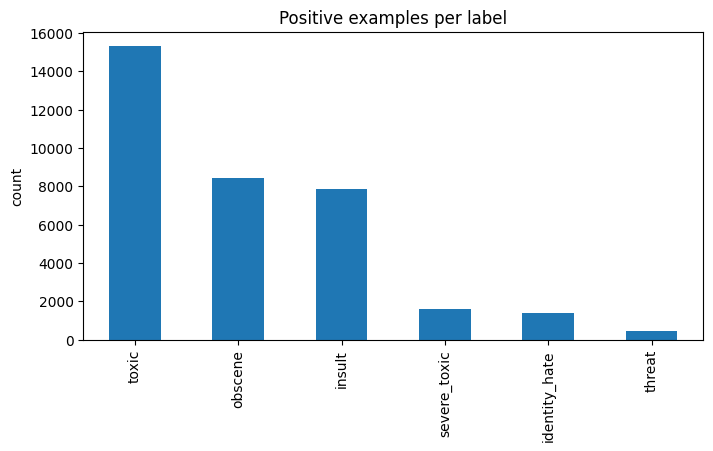

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64

% of comments with NO label at all (clean): 89.8%


In [4]:
# Quick look at how imbalanced each label is.
# This matters a lot for a multi-label problem: most comments are NOT toxic at all,
# and within toxic comments, some labels (like "threat") are rare.
label_counts = train_df[LABEL_COLS].sum().sort_values(ascending=False)
label_counts.plot(kind="bar", figsize=(8, 4), title="Positive examples per label")
plt.ylabel("count")
plt.show()

print(label_counts)
print(f"\n% of comments with NO label at all (clean): "
      f"{(train_df[LABEL_COLS].sum(axis=1) == 0).mean() * 100:.1f}%")


## 3. Text cleaning

Nothing fancy -- lowercase, strip newlines/IP-addresses/extra punctuation. Keep it light:
TF-IDF and linear models work fine on lightly-cleaned text, and over-cleaning can throw
away signal (e.g. repeated punctuation like "!!!" or all-caps can correlate with toxicity).


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}", " ", text)  # strip IP addresses
    text = re.sub(r"http\S+|www\S+", " ", text)  # strip URLs
    text = re.sub(r"[^a-z0-9\s']", " ", text)  # strip punctuation except apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["comment_text"].astype(str).apply(clean_text)
test_df["clean_text"] = test_df["comment_text"].astype(str).apply(clean_text)

train_df[["comment_text", "clean_text"]].head(3)


,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d'aww he matches this background colour i'm se...
2,"Hey man, I'm really not trying to edit war. It...",hey man i'm really not trying to edit war it's...


## 4. Train / validation split

We split `train.csv` ourselves to get a validation set, since the real `test.csv` labels
are only used for final reporting (and some rows are masked with -1).


In [6]:
from sklearn.model_selection import train_test_split

X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df["clean_text"],
    train_df[LABEL_COLS].values,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print("train:", X_train_text.shape[0], " val:", X_val_text.shape[0])


train: 127656  val: 31915


## 5. TF-IDF features

We turn text into numeric vectors with TF-IDF (term frequency–inverse document frequency).
Word-level + character-level n-grams together usually work best for toxic comment text,
because character n-grams catch misspellings people use to dodge filters (e.g. "id*ot").


In [7]:
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=40000,
    min_df=2,
)

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=40000,
    min_df=2,
)

from scipy.sparse import hstack

print("Fitting word vectorizer...")
X_train_word = word_vectorizer.fit_transform(X_train_text)
X_val_word = word_vectorizer.transform(X_val_text)

print("Fitting char vectorizer...")
X_train_char = char_vectorizer.fit_transform(X_train_text)
X_val_char = char_vectorizer.transform(X_val_text)

X_train = hstack([X_train_word, X_train_char]).tocsr()
X_val = hstack([X_val_word, X_val_char]).tocsr()

print("Feature matrix shape (train):", X_train.shape)


Fitting word vectorizer...
Fitting char vectorizer...
Feature matrix shape (train): (127656, 80000)


## 6. Models

Each model below is wrapped in `OneVsRestClassifier`. This trains **6 separate binary
classifiers internally** (one per label) and lets each predict independently — exactly
what multi-label classification needs. No extra setup required on our end beyond passing
the full `(n_samples, 6)` label matrix.

A note on `LinearSVC`: it doesn't output probabilities by default (just a decision score),
so we wrap it in `CalibratedClassifierCV` to get probability outputs — needed for the
ROC-AUC metric the competition actually uses.


In [8]:
def evaluate_model(name, model, X_val, y_val, label_cols):
    """Prints per-label ROC-AUC and the mean column-wise AUC (the competition metric)."""
    y_pred_proba = model.predict_proba(X_val)

    # OneVsRestClassifier with predict_proba returns shape (n_samples, n_labels) directly
    aucs = []
    print(f"--- {name} ---")
    for i, col in enumerate(label_cols):
        auc = roc_auc_score(y_val[:, i], y_pred_proba[:, i])
        aucs.append(auc)
        print(f"  {col:15s} AUC: {auc:.4f}")
    mean_auc = np.mean(aucs)
    print(f"  {'MEAN AUC':15s}: {mean_auc:.4f}\n")
    return mean_auc, y_pred_proba


In [9]:
# ---- Naive Bayes ----
nb_model = OneVsRestClassifier(MultinomialNB())
nb_model.fit(X_train, y_train)
nb_auc, nb_proba = evaluate_model("Naive Bayes", nb_model, X_val, y_val, LABEL_COLS)


--- Naive Bayes ---
  toxic           AUC: 0.9522
  severe_toxic    AUC: 0.9520
  obscene         AUC: 0.9533
  threat          AUC: 0.8770
  insult          AUC: 0.9518
  identity_hate   AUC: 0.8933
  MEAN AUC       : 0.9299



In [10]:
# ---- Logistic Regression ----
logreg_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=4.0, random_state=RANDOM_STATE)
)
logreg_model.fit(X_train, y_train)
logreg_auc, logreg_proba = evaluate_model("Logistic Regression", logreg_model, X_val, y_val, LABEL_COLS)


--- Logistic Regression ---
  toxic           AUC: 0.9776
  severe_toxic    AUC: 0.9855
  obscene         AUC: 0.9895
  threat          AUC: 0.9844
  insult          AUC: 0.9805
  identity_hate   AUC: 0.9811
  MEAN AUC       : 0.9831



In [11]:
# ---- Linear SVM ----
# LinearSVC has no predict_proba, so we calibrate it to get probability-like scores.
svm_base = LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000)
svm_model = OneVsRestClassifier(
    CalibratedClassifierCV(svm_base, method="sigmoid", cv=3)
)
svm_model.fit(X_train, y_train)
svm_auc, svm_proba = evaluate_model("Linear SVM", svm_model, X_val, y_val, LABEL_COLS)


--- Linear SVM ---
  toxic           AUC: 0.9755
  severe_toxic    AUC: 0.9721
  obscene         AUC: 0.9872
  threat          AUC: 0.9854
  insult          AUC: 0.9777
  identity_hate   AUC: 0.9764
  MEAN AUC       : 0.9791



## 7. Compare all three baselines

In [12]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "Mean AUC": [nb_auc, logreg_auc, svm_auc],
}).sort_values("Mean AUC", ascending=False).reset_index(drop=True)

results

,Model,Mean AUC
0,Logistic Regression,0.983083
1,Linear SVM,0.979050
2,Naive Bayes,0.929928


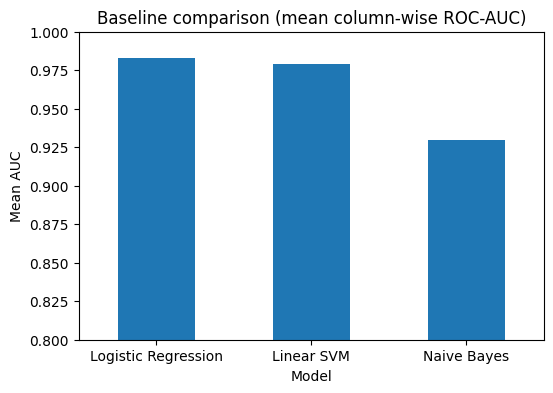

In [13]:
results.plot(x="Model", y="Mean AUC", kind="bar", legend=False, figsize=(6, 4),
             title="Baseline comparison (mean column-wise ROC-AUC)")
plt.ylim(0.8, 1.0)
plt.ylabel("Mean AUC")
plt.xticks(rotation=0)
plt.show()


## 8. Per-label comparison (bonus, optional)

shows which labels are hardest for which model. Typically `threat`
and `identity_hate` are the lowest-scoring labels for every model, because they have the
fewest positive training examples.


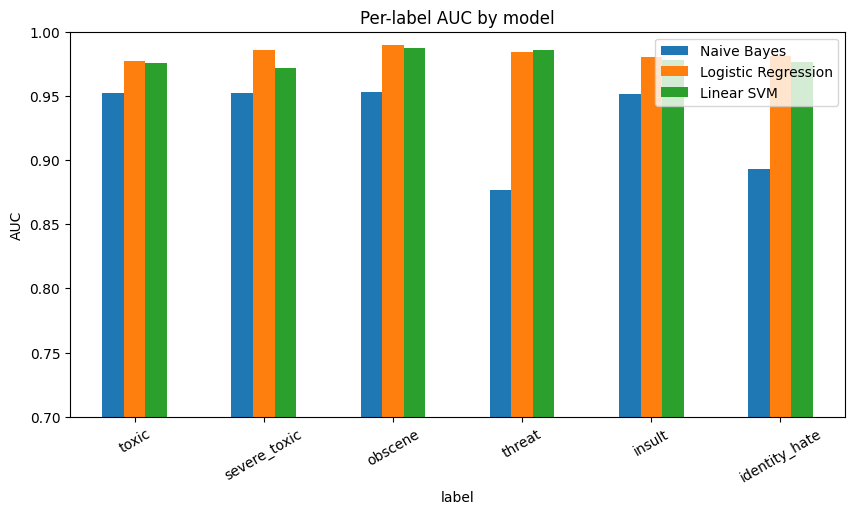

,label,Naive Bayes,Logistic Regression,Linear SVM
0,toxic,0.952184,0.977576,0.975510
1,severe_toxic,0.951977,0.985466,0.972091
2,obscene,0.953342,0.989464,0.987189
3,threat,0.877027,0.984422,0.985442
4,insult,0.951783,0.980502,0.977677
5,identity_hate,0.893255,0.981070,0.976393


In [14]:
per_label_results = pd.DataFrame({
    "label": LABEL_COLS,
    "Naive Bayes": [roc_auc_score(y_val[:, i], nb_proba[:, i]) for i in range(6)],
    "Logistic Regression": [roc_auc_score(y_val[:, i], logreg_proba[:, i]) for i in range(6)],
    "Linear SVM": [roc_auc_score(y_val[:, i], svm_proba[:, i]) for i in range(6)],
})

per_label_results.set_index("label").plot(kind="bar", figsize=(10, 5),
                                            title="Per-label AUC by model")
plt.ylabel("AUC")
plt.ylim(0.7, 1.0)
plt.xticks(rotation=30)
plt.show()

per_label_results


## 9. Generate Submission Files

Each model produces its own submission CSV.
- On **Colab**: saved to Google Drive (`jigsaw-data/`)
- On **local**: saved next to the notebook

All files follow the Kaggle format: one probability per label per test comment.

In [15]:
# build test feature matrix (same vectorizers fitted on train)
X_test_word = word_vectorizer.transform(test_df["clean_text"])
X_test_char = char_vectorizer.transform(test_df["clean_text"])
X_test = hstack([X_test_word, X_test_char]).tocsr()
print(f"Test feature matrix shape: {X_test.shape}")

Test feature matrix shape: (153164, 80000)


In [16]:
# ---- Naive Bayes submission ----
nb_test_proba = nb_model.predict_proba(X_test)
submission_nb = pd.DataFrame(nb_test_proba, columns=LABEL_COLS)
submission_nb.insert(0, "id", test_df["id"])
NB_PATH = (DATA_DIR + "submission_naivebayes.csv") if ENV == "colab" \
           else "submission_naivebayes.csv"
submission_nb.to_csv(NB_PATH, index=False)
print(f"Saved: {NB_PATH}")
submission_nb.head(2)

Saved: /content/drive/MyDrive/jigsaw-data/submission_naivebayes.csv


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,1.000000,2.879716e-04,1.000000,6.797716e-10,0.999995,0.000071
1,0000247867823ef7,0.000254,7.544490e-07,0.000091,6.790099e-08,0.000073,0.000002


In [17]:
# ---- Logistic Regression submission ----
logreg_test_proba = logreg_model.predict_proba(X_test)
submission_lr = pd.DataFrame(logreg_test_proba, columns=LABEL_COLS)
submission_lr.insert(0, "id", test_df["id"])
LR_PATH = (DATA_DIR + "submission_logreg.csv") if ENV == "colab" \
           else "submission_logreg.csv"
submission_lr.to_csv(LR_PATH, index=False)
print(f"Saved: {LR_PATH}")
submission_lr.head(2)

Saved: /content/drive/MyDrive/jigsaw-data/submission_logreg.csv


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,1.000000,0.300249,0.999992,0.053455,0.994505,0.443424
1,0000247867823ef7,0.000747,0.000360,0.000327,0.000202,0.001156,0.001155


In [18]:
# ---- Linear SVM submission ----
svm_test_proba = svm_model.predict_proba(X_test)
submission_svm = pd.DataFrame(svm_test_proba, columns=LABEL_COLS)
submission_svm.insert(0, "id", test_df["id"])
SVM_PATH = (DATA_DIR + "submission_svm.csv") if ENV == "colab" \
            else "submission_svm.csv"
submission_svm.to_csv(SVM_PATH, index=False)
print(f"Saved: {SVM_PATH}")
submission_svm.head(2)

Saved: /content/drive/MyDrive/jigsaw-data/submission_svm.csv


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,0.999998,0.082968,0.999989,0.160253,0.977209,0.150535
1,0000247867823ef7,0.003586,0.000749,0.000822,0.000224,0.002123,0.002438


## Key Findings — Baselines (Naive Bayes, Logistic Regression, Linear SVM)

### Overall comparison

| Model | Mean ROC-AUC (validation) |
|---|---|
| Logistic Regression | **0.9830** |
| Linear SVM | 0.9790 |
| Naive Bayes | 0.9298 |

**Best baseline:** Logistic Regression, with a mean AUC of 0.9830.

### Naive Bayes lags meaningfully behind, not just slightly

The gap between Naive Bayes (0.9298) and the other two models (~0.98) is about
5 percentage points — which sounds small, but is actually a large gap at this end
of the AUC scale, where most models are already bunched up near 1.0. A 5-point
difference here means Naive Bayes is making meaningfully more ranking errors than
the other two, not just performing marginally worse.

This lines up with a known limitation of Naive Bayes: it assumes every word in a
comment is independent of every other word, given the label. Toxic language often
relies on combinations and context — phrases, intensifiers, sarcasm — that a
word-independence assumption can't capture, while Logistic Regression and Linear
SVM (both fit directly on the same TF-IDF feature space, optimizing a real decision
boundary rather than a probabilistic independence assumption) handle these
interactions better by construction.

### The hardest and easiest labels overall

- **Hardest label across all models: `threat`** — consistent with it being the
  rarest label in the dataset (fewest positive training examples for any model to
  learn from).
- **Easiest label across all models: `obscene`** — consistent with it being one of
  the most common labels, giving every model plenty of examples to learn from.

This matches the expected pattern: more training examples for a label generally
means better performance on that label, and `threat`/`obscene` sit at opposite
ends of that spectrum in this dataset (see the label-frequency chart in
`02_eda.ipynb`).

### A genuinely surprising result: each model's *weakest* label doesn't always match the *rarest* label

| Model | Weakest label | Is this the rarest label for that model? |
|---|---|---|
| Naive Bayes | `threat` | Yes — matches the expected "rare label = hard label" pattern |
| Logistic Regression | `toxic` | **No** — `toxic` is the *most common* label in the dataset |
| Linear SVM | `severe_toxic` | No — `severe_toxic` is rare, but not the rarest (`threat` is) |

Naive Bayes behaves as expected — its weakest label is the rarest one. But
Logistic Regression's weakest label being `toxic` is notable, since `toxic` has
*more* training examples than any other label. More data normally means a model
does better, not worse, on that label — so this isn't simply a data-scarcity story.

A plausible explanation: `toxic` is the broadest, most loosely-defined category of
the six. A huge variety of comments get labeled `toxic` — everything from mild
rudeness to severe insults — which makes the decision boundary between
"toxic" and "not toxic" fuzzier and harder to draw cleanly, even with abundant
data. By contrast, `severe_toxic`, `threat`, and `identity_hate` are narrower,
more clear-cut categories: rarer, but more consistent in what they actually look
like when they do occur. This would explain why a precise linear boundary
(Logistic Regression, SVM) can struggle more on the "common but fuzzy" label than
on a "rare but distinct" one — worth stating as a hypothesis in your report rather
than a confirmed conclusion, since confirming it properly would need a closer look
at the specific comments Logistic Regression gets wrong on `toxic`.

### Why the models differ

- **Naive Bayes** assumes word features are independent given the label — the
  fastest of the three to train, but this simplifying assumption appears to cost
  it real accuracy on this dataset, not just a marginal amount.
- **Logistic Regression** and **Linear SVM** both fit a linear decision boundary
  directly over the same TF-IDF features, and land close to each other in overall
  AUC (within 0.004) — but diverge on *which* label they each find hardest,
  suggesting their different optimization objectives (log-loss vs. hinge loss)
  lead to slightly different decision boundaries even on the same features.

### Practical takeaways

- All three baselines train in well under a few minutes on CPU — no GPU needed.
- Logistic Regression (0.9830) is the bar your BiLSTM and DistilBERT results need
  to clear to justify their added training cost and complexity.
- TF-IDF + Logistic Regression is a strong, cheap baseline — worth remembering for
  future projects before reaching for something heavier.


## Summary

- This notebook treats the problem correctly as **multi-label**: 6 independent yes/no
  predictions per comment, not one class out of 6.
- `OneVsRestClassifier` is what makes a normally-binary model (NB, LogReg, SVM) work
  in this multi-label setting — it trains one binary copy of the model per label.
- The competition metric is the **mean of the per-label ROC-AUC scores**, which is what
  `evaluate_model()` reports above.
- Next step: compare these numbers against your teammate's BiLSTM and your DistilBERT
  results using the same mean-AUC metric, so all models are judged the same way.
